In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
FASTTEXT_PATH = 'cc.id.300.vec' 
TRAIN_FILE = 'id_gsd-ud-train.conllu'
TEST_FILE = 'id_gsd-ud-test.conllu'

# Hyperparameters
EMBEDDING_DIM = 300  
HIDDEN_DIM = 256  
OUTPUT_DIM = None    
N_LAYERS = 2          
BIDIRECTIONAL = True
DROPOUT = 0.33
BATCH_SIZE = 32
MAX_LEN = 80          
EPOCHS = 20
LEARNING_RATE = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
def parse_conllu(filepath):
    sentences = []
    current_sent = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                if current_sent:
                    sentences.append(current_sent)
                    current_sent = []
                continue
            parts = line.split('\t')
            if '-' in parts[0]: continue 
            current_sent.append((parts[1], parts[3])) 
    if current_sent: sentences.append(current_sent)
    return sentences

train_data = parse_conllu(TRAIN_FILE)
test_data = parse_conllu(TEST_FILE)

word_to_ix = {'<PAD>': 0, '<UNK>': 1}
tag_to_ix = {'<PAD>': 0}

for sent in train_data:
    for word, tag in sent:
        if word not in word_to_ix: word_to_ix[word] = len(word_to_ix)
        if tag not in tag_to_ix: tag_to_ix[tag] = len(tag_to_ix)

ix_to_tag = {v: k for k, v in tag_to_ix.items()}
OUTPUT_DIM = len(tag_to_ix)

print(f"Vocab Size: {len(word_to_ix)}")
print(f"Number of Tags: {OUTPUT_DIM}")

class POSDataset(Dataset):
    def __init__(self, data, word_to_ix, tag_to_ix, max_len):
        self.data = data
        self.word_to_ix = word_to_ix
        self.tag_to_ix = tag_to_ix
        self.max_len = max_len
        
    def __len__(self): return len(self.data)
    
    def __getitem__(self, idx):
        sent = self.data[idx]
        words = [self.word_to_ix.get(w, 1) for w, t in sent]
        tags = [self.tag_to_ix[t] for w, t in sent]
        
        if len(words) < self.max_len:
            words += [0] * (self.max_len - len(words))
            tags += [0] * (self.max_len - len(tags))
        else:
            words = words[:self.max_len]
            tags = tags[:self.max_len]
            
        return torch.tensor(words), torch.tensor(tags)

train_loader = DataLoader(POSDataset(train_data, word_to_ix, tag_to_ix, MAX_LEN), 
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(POSDataset(test_data, word_to_ix, tag_to_ix, MAX_LEN), 
                         batch_size=BATCH_SIZE, shuffle=False)

Vocab Size: 19225
Number of Tags: 17


In [4]:
class BiLSTMPOSTagger(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        
        self.lstm = nn.LSTM(emb_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=bidirectional,
                            dropout=dropout if n_layers > 1 else 0,
                            batch_first=True)
        
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        
        outputs, (hidden, cell) = self.lstm(embedded)
        
        predictions = self.fc(self.dropout(outputs))
        return predictions

model = BiLSTMPOSTagger(len(word_to_ix), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, 
                        N_LAYERS, BIDIRECTIONAL, DROPOUT, word_to_ix['<PAD>'])
model = model.to(device)

In [5]:
def load_fasttext(model, word_to_ix, path):
    print(f"Loading FastText from {path}...")
    count = 0
    try:
        with open(path, 'r', encoding='utf-8', newline='\n', errors='ignore') as f:
            n, d = map(int, f.readline().split())
            for line in f:
                tokens = line.rstrip().split(' ')
                word = tokens[0]
                if word in word_to_ix:
                    vec = torch.tensor([float(x) for x in tokens[1:]])
                    model.embedding.weight.data[word_to_ix[word]] = vec
                    count += 1
        print(f"Loaded {count} vectors.")
    except FileNotFoundError:
        print("FastText file not found! Training with random embeddings.")

In [6]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=tag_to_ix['<PAD>'])

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for text, tags in train_loader:
        text, tags = text.to(device), tags.to(device)
        optimizer.zero_grad()
        
        predictions = model(text)
        predictions = predictions.view(-1, OUTPUT_DIM)
        tags = tags.view(-1)
        
        loss = criterion(predictions, tags)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(train_loader):.4f}")

Epoch 1/20 | Loss: 1.2017
Epoch 2/20 | Loss: 0.6066
Epoch 3/20 | Loss: 0.4412
Epoch 4/20 | Loss: 0.3420
Epoch 5/20 | Loss: 0.2812
Epoch 6/20 | Loss: 0.2345
Epoch 7/20 | Loss: 0.2033
Epoch 8/20 | Loss: 0.1759
Epoch 9/20 | Loss: 0.1522
Epoch 10/20 | Loss: 0.1346
Epoch 11/20 | Loss: 0.1226
Epoch 12/20 | Loss: 0.1121
Epoch 13/20 | Loss: 0.1006
Epoch 14/20 | Loss: 0.0935
Epoch 15/20 | Loss: 0.0869
Epoch 16/20 | Loss: 0.0790
Epoch 17/20 | Loss: 0.0735
Epoch 18/20 | Loss: 0.0678
Epoch 19/20 | Loss: 0.0648
Epoch 20/20 | Loss: 0.0600


In [7]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for text, tags in test_loader:
        text, tags = text.to(device), tags.to(device)
        predictions = model(text)
        
        predictions = predictions.argmax(dim=-1)
        
        preds_flat = predictions.view(-1).cpu().numpy()
        tags_flat = tags.view(-1).cpu().numpy()
        
        mask = (tags_flat != tag_to_ix['<PAD>'])
        all_preds.extend(preds_flat[mask])
        all_labels.extend(tags_flat[mask])

y_true = [ix_to_tag[ix] for ix in all_labels]
y_pred = [ix_to_tag[ix] for ix in all_preds]
labels = sorted([t for t in tag_to_ix.keys() if t != '<PAD>'])

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
print(f"Accuracy: {acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))


FINAL RESULTS
Pure Accuracy: 0.8950
Precision:     0.8971
Recall:        0.8950
F1 Score:      0.8953
------------------------------

Classification Report:
              precision    recall  f1-score   support

         ADJ       0.79      0.74      0.76       420
         ADP       0.97      0.96      0.97      1146
         ADV       0.85      0.84      0.84       483
         AUX       0.99      1.00      0.99        95
       CCONJ       0.97      0.91      0.94       369
         DET       0.91      0.91      0.91       373
        NOUN       0.85      0.85      0.85      2531
         NUM       0.92      0.82      0.86       399
        PART       0.92      0.90      0.91        49
        PRON       0.98      0.94      0.96       494
       PROPN       0.82      0.90      0.86      2182
       PUNCT       1.00      1.00      1.00      1678
       SCONJ       0.71      0.82      0.76       142
         SYM       1.00      0.97      0.98        30
        VERB       0.92      0.

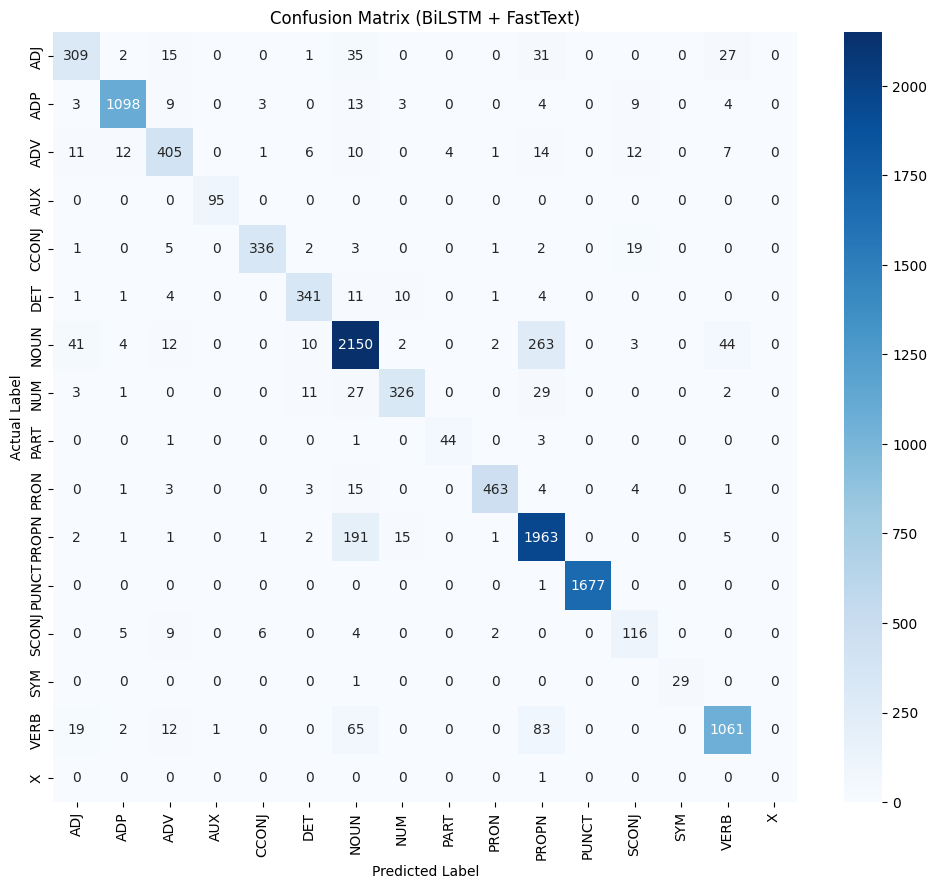

In [8]:
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('Confusion Matrix (BiLSTM + FastText)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()